# Hands-on Image Retrieval Workshop

In this notebook you will recreate the core search technology used in the prototype.

The goal is simple: given a query image, find the most visually similar objects in a gallery.

We will use:

- **DINOv2** to turn each image into an embedding vector.
- **FAISS** to search quickly through those vectors.
- **Top-k retrieval** to inspect the best candidate objects.

Run the notebook from top to bottom. The code is intentionally straightforward so you can modify it during the workshop.

## Notebook Navigation

1. [Correct Folder Structure](#correct-folder-structure)
2. [Optional Package Installation](#optional-package-installation)
3. [Optional Dataset Builder](#optional-abo-dataset-builder)
4. [Imports and Paths](#imports-and-paths)
5. [Load Images from the Workshop Folders](#load-images)
6. [Quick Preview](#quick-preview)
7. [Load DINOv2](#load-dinov2)
8. [Embed Images](#embed-images)
9. [Build the FAISS Gallery Index](#build-faiss-index)
10. [Search One Query Image](#search-one-query)
11. [Visualize the Top-3 Results](#visualize-top3)
12. [Search Every Query Image](#search-every-query)
13. [Prediction Statistics](#prediction-statistics)
14. [Optional Single-Item Visualizations](#optional-single-item-visualizations)
15. [Try It Yourself](#try-it-yourself)

<a id="correct-folder-structure"></a>

## 1. Correct Folder Structure

Before running the search, put your images into this structure:

```text
workshop_materials/
  data/
    gallery/
      object_001/
        img_001.jpg
        img_002.jpg
      object_002/
        img_001.jpg
    query/
      query_001.jpg
      query_002.jpg
    query_labels.csv
```

Rules:

- Each known object gets one folder inside `data/gallery/`.
- Put multiple images of the same object in the same object folder.
- Put query images directly inside `data/query/`.
- Folder names such as `object_001` are the object identifiers.
- `query_labels.csv` is optional, but useful if you want to check accuracy.

Example `query_labels.csv`:

```csv
query_name,true_object
query_001.jpg,object_001
query_002.jpg,object_002
query_unknown.jpg,
```

<a id="optional-package-installation"></a>

## 2. Optional Package Installation

If this notebook runs in a fresh environment, uncomment and run the next cell once.

If the packages are already installed, skip it.

In [113]:
# Uncomment if needed:
# %pip install -q pillow numpy pandas matplotlib torch transformers faiss-cpu tqdm requests

<a id="optional-abo-dataset-builder"></a>

## Optional: Dataset Builder

This optional step uses `scripts/abo_retrieval_dataset_builder_v3.py` to build a fresh retrieval dataset from the Amazon Berkeley Objects dataset.

It filters objects by product type, downloads 360-degree image sequences, samples gallery views, holds out one query image per object, and can write `query_labels.csv`.

The command is commented out by default because it downloads external data and writes into `workshop_materials/data/`. Uncomment it only when you want to rebuild the workshop dataset.


In [114]:
# Optional ABO dataset builder. Uncomment and edit these lines if you want to create a fresh workshop dataset.

PRODUCT_TYPE = "SOFA"  # Change to "CHAIR" or "TABLE" if desired
MAX_GALLERY_IMAGES = 6  # For 72 source frames this picks frames 1, 24, 48, 72

from pathlib import Path
import subprocess
import sys

current_dir = Path.cwd().resolve()
step_root = next(
    candidate for candidate in [current_dir, *current_dir.parents]
    if (candidate / "scripts" / "abo_retrieval_dataset_builder_v3.py").exists()
)
workshop_dir = step_root / "workshop_materials"
abo_script = step_root / "scripts" / "abo_retrieval_dataset_builder_v3.py"
abo_output = workshop_dir / "data"

abo_command = [
    sys.executable,
    str(abo_script),
    "--product-type", PRODUCT_TYPE,
    "--output", str(abo_output),
    "--max-objects", "20",
    "--max-gallery-images", str(MAX_GALLERY_IMAGES),
    "--write-query-labels",
]

print("Running:", " ".join(abo_command))
subprocess.run(abo_command, cwd=step_root.parent, check=True)
print("ABO workshop dataset saved to:", abo_output)


Running: /Library/Developer/CommandLineTools/usr/bin/python3 /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/scripts/abo_retrieval_dataset_builder_v3.py --product-type SOFA --output /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/workshop_materials/data --max-objects 20 --max-gallery-images 6 --write-query-labels


/Users/memerchik/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Reading listing metadata 1/16 (listings_0.json.gz)...
Reading listing metadata 2/16 (listings_1.json.gz)...
Reading listing metadata 3/16 (listings_2.json.gz)...
Reading listing metadata 4/16 (listings_3.json.gz)...
Reading listing metadata 5/16 (listings_4.json.gz)...
Reading listing metadata 6/16 (listings_5.json.gz)...
Reading listing metadata 7/16 (listings_6.json.gz)...
Reading listing metadata 8/16 (listings_7.json.gz)...
Reading listing metadata 9/16 (listings_8.json.gz)...
Reading listing metadata 10/16 (listings_9.json.gz)...
Reading listing metadata 11/16 (listings_a.json.gz)...
Reading listing metadata 12/16 (listings_b.json.gz)...
Reading listing metadata 13/16 (listings_c.json.gz)...
Reading listing me

Done. Dataset saved under: /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/workshop_materials/data
ABO workshop dataset saved to: /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/workshop_materials/data


Wrote labels: /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/workshop_materials/data/query_labels.csv


<a id="imports-and-paths"></a>

## 3. Imports and Paths

This cell finds the `workshop_materials/` folder automatically, so the notebook works whether you open it from the notebook folder or from the repository root.

In [115]:
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from tqdm.auto import tqdm


def find_workshop_dir():
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        possible_locations = [
            candidate,
            candidate / "workshop_materials",
            candidate / "step_1" / "workshop_materials",
        ]
        for location in possible_locations:
            if (location / "data").exists() and (location / "notebooks").exists():
                return location.resolve()
    raise FileNotFoundError("Could not find workshop_materials/. Run this notebook from inside the repository.")


WORKSHOP_DIR = find_workshop_dir()
DATA_DIR = WORKSHOP_DIR / "data"
GALLERY_DIR = DATA_DIR / "gallery"
QUERY_DIR = DATA_DIR / "query"
LABELS_PATH = DATA_DIR / "query_labels.csv"
OUTPUTS_DIR = WORKSHOP_DIR / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print("Workshop folder:", WORKSHOP_DIR)
print("Gallery folder:", GALLERY_DIR)
print("Query folder:", QUERY_DIR)
print("Outputs folder:", OUTPUTS_DIR)

Workshop folder: /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/workshop_materials
Gallery folder: /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/workshop_materials/data/gallery
Query folder: /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/workshop_materials/data/query
Outputs folder: /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/workshop_materials/outputs


<a id="load-images"></a>

## 4. Load Images from the Workshop Folders

The gallery is the known collection. The query folder contains images we want to search for.

In [116]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"}


def is_image_file(path):
    return path.suffix.lower() in IMAGE_EXTENSIONS


def list_images(folder):
    if not folder.exists():
        return []
    return sorted(path for path in folder.rglob("*") if path.is_file() and is_image_file(path))


def load_gallery_dataframe(gallery_dir):
    rows = []
    for object_dir in sorted(gallery_dir.iterdir() if gallery_dir.exists() else []):
        if not object_dir.is_dir():
            continue
        object_id = object_dir.name
        for image_path in list_images(object_dir):
            rows.append({
                "object_id": object_id,
                "image_name": image_path.name,
                "image_path": str(image_path.resolve()),
                "image_relpath": str(image_path.relative_to(gallery_dir)),
            })
    return pd.DataFrame(rows)


gallery_df = load_gallery_dataframe(GALLERY_DIR)
query_paths = list_images(QUERY_DIR)

if gallery_df.empty:
    raise ValueError("No gallery images found. Add images under data/gallery/object_001/, object_002/, etc.")

if not query_paths:
    raise ValueError("No query images found. Add images directly under data/query/.")

print(f"Gallery images: {len(gallery_df)}")
print(f"Gallery objects: {gallery_df['object_id'].nunique()}")
print(f"Query images: {len(query_paths)}")

display(gallery_df.groupby("object_id").size().rename("image_count").reset_index())

Gallery images: 120
Gallery objects: 20
Query images: 20


,object_id,image_count
0,object_001,6
1,object_002,6
2,object_003,6
3,object_004,6
4,object_005,6
5,object_006,6
6,object_007,6
7,object_008,6
8,object_009,6
9,object_010,6


<a id="quick-preview"></a>

## 5. Quick Preview

This preview is just to check that the notebook is reading the images you expected.

Gallery preview


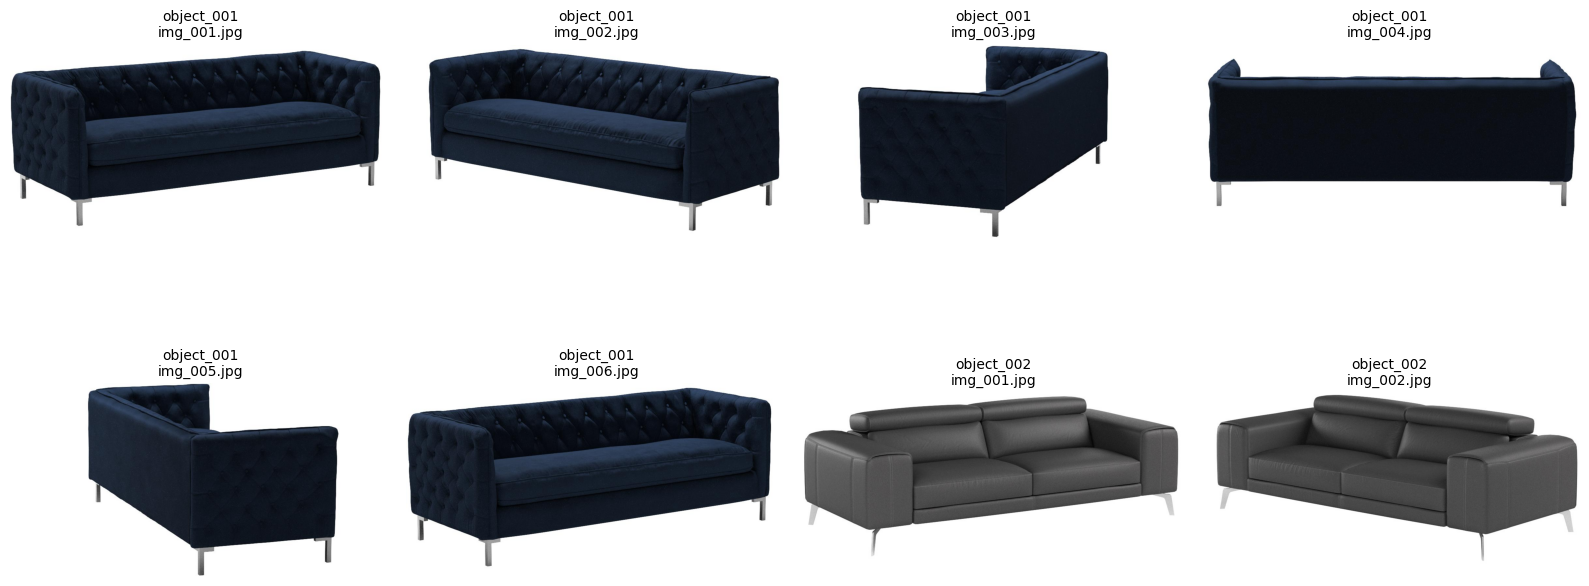

Query preview


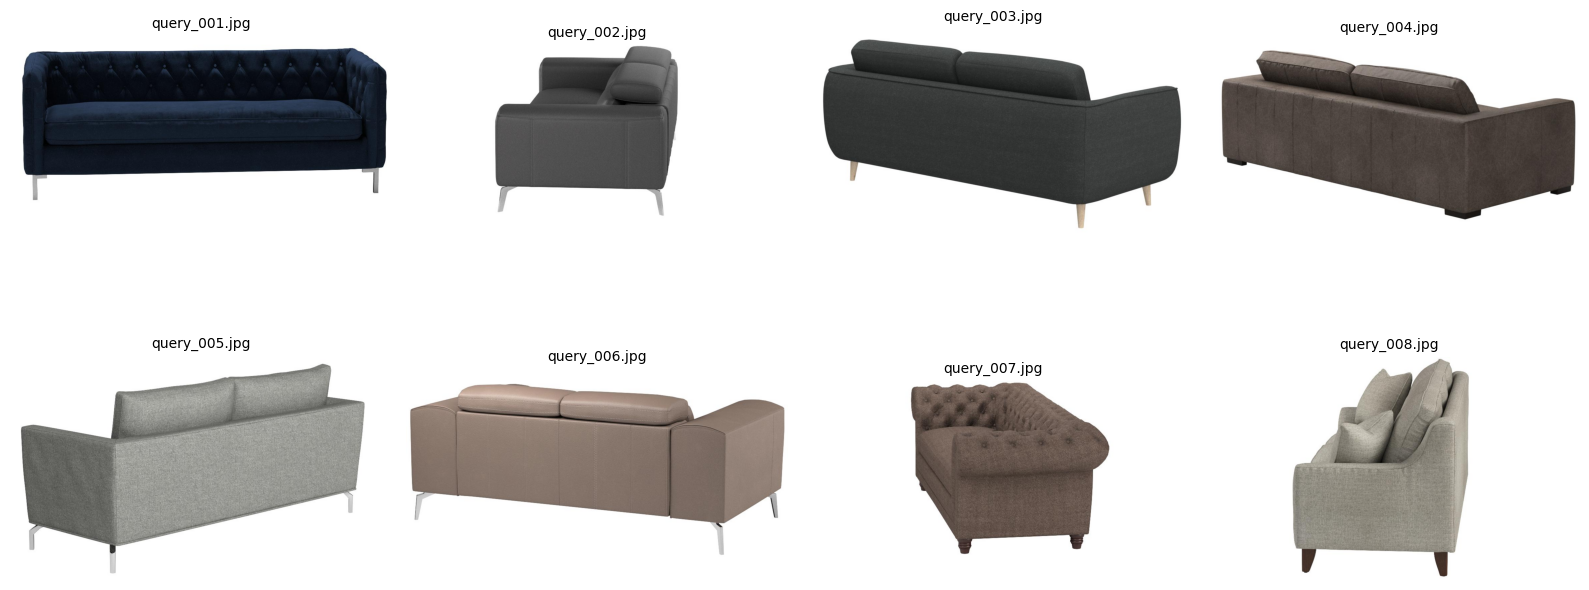

In [117]:
def load_rgb(path):
    with Image.open(path) as image:
        image = ImageOps.exif_transpose(image)
        return image.convert("RGB")


def show_image_grid(paths, titles, max_images=8):
    paths = paths[:max_images]
    if not paths:
        print("No images to show.")
        return
    cols = min(4, len(paths))
    rows = int(np.ceil(len(paths) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis("off")
    for i, path in enumerate(paths):
        axes[i].imshow(load_rgb(path))
        axes[i].set_title(titles[i] if titles else path.name, fontsize=10)
    plt.tight_layout()
    plt.show()


sample_gallery_paths = [Path(path) for path in gallery_df["image_path"].head(8)]
sample_gallery_titles = [f"{row.object_id}\n{row.image_name}" for row in gallery_df.head(8).itertuples()]

print("Gallery preview")
show_image_grid(sample_gallery_paths, sample_gallery_titles)

print("Query preview")
show_image_grid(query_paths, [path.name for path in query_paths])

<a id="load-dinov2"></a>

## 6. Load DINOv2

DINOv2 converts each image into a vector. A vector is just a list of numbers, but it carries visual information about the image.

Images that look similar should have vectors that are close together.

In [118]:
import torch
from transformers import AutoImageProcessor, AutoModel

MODEL_NAME = "facebook/dinov2-base"

if torch.cuda.is_available():
    DEVICE = "cuda"
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

print("Loaded model:", MODEL_NAME)
print("Device:", DEVICE)

Loaded model: facebook/dinov2-base
Device: mps


<a id="embed-images"></a>

## 7. Embed Images

This function turns image files into normalized vectors. Normalization makes cosine similarity easy to compute.

In [119]:
def l2_normalize(vectors):
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    return vectors / np.maximum(norms, 1e-12)


@torch.inference_mode()
def embed_images(image_paths, batch_size=8):
    all_embeddings = []
    for start in tqdm(range(0, len(image_paths), batch_size), desc="Embedding images"):
        batch_paths = image_paths[start:start + batch_size]
        images = [load_rgb(path) for path in batch_paths]
        inputs = processor(images=images, return_tensors="pt")
        inputs = {key: value.to(DEVICE) for key, value in inputs.items()}

        outputs = model(**inputs)
        if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
            embeddings = outputs.pooler_output
        else:
            embeddings = outputs.last_hidden_state.mean(dim=1)

        all_embeddings.append(embeddings.detach().cpu().float().numpy())

    embeddings = np.concatenate(all_embeddings, axis=0).astype("float32")
    return l2_normalize(embeddings)

<a id="build-faiss-index"></a>

## 8. Build the FAISS Gallery Index

FAISS stores the gallery vectors and lets us search for the nearest ones quickly.

Because our vectors are normalized, inner product search is equivalent to cosine similarity.

In [120]:
import faiss

gallery_paths = [Path(path) for path in gallery_df["image_path"]]
gallery_embeddings = embed_images(gallery_paths, batch_size=8)

embedding_dim = gallery_embeddings.shape[1]
index = faiss.IndexFlatIP(embedding_dim)
index.add(gallery_embeddings)

np.save(OUTPUTS_DIR / "gallery_embeddings.npy", gallery_embeddings)
faiss.write_index(index, str(OUTPUTS_DIR / "gallery_faiss.index"))
gallery_df[["object_id", "image_relpath", "image_name"]].to_csv(OUTPUTS_DIR / "gallery_metadata.csv", index=False)

print("Gallery index built.")
print("Embedding shape:", gallery_embeddings.shape)
print("Saved outputs to:", OUTPUTS_DIR)

Embedding images: 100%|██████████| 15/15 [00:02<00:00,  6.78it/s]

Gallery index built.
Embedding shape: (120, 768)
Saved outputs to: /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/workshop_materials/outputs


<a id="search-one-query"></a>

## 9. Search One Query Image

Now we embed one query image and ask FAISS for the nearest gallery images.

Then we group the image matches by object folder, so the result is object-level rather than just image-level.

In [121]:
def object_results_from_image_matches(scores, indices, top_k_objects=5):
    best_by_object = {}
    for score, idx in zip(scores, indices):
        if idx < 0:
            continue
        row = gallery_df.iloc[int(idx)]
        object_id = row["object_id"]
        match = {
            "object_id": object_id,
            "score": float(score),
            "image_name": row["image_name"],
            "image_path": row["image_path"],
        }
        if object_id not in best_by_object or match["score"] > best_by_object[object_id]["score"]:
            best_by_object[object_id] = match

    return sorted(best_by_object.values(), key=lambda item: item["score"], reverse=True)[:top_k_objects]


def search_query(query_path, top_k_images=30, top_k_objects=5):
    query_embedding = embed_images([query_path], batch_size=1)
    search_count = min(top_k_images, len(gallery_df))
    scores, indices = index.search(query_embedding, search_count)
    return object_results_from_image_matches(scores[0], indices[0], top_k_objects=top_k_objects)


selected_query = query_paths[0]
single_query_results = search_query(selected_query, top_k_images=30, top_k_objects=5)

print("Selected query:", selected_query.name)
display(pd.DataFrame(single_query_results))

Embedding images: 100%|██████████| 1/1 [00:00<00:00, 38.53it/s]

Selected query: query_001.jpg


,object_id,score,image_name,image_path
0,object_001,0.943413,img_001.jpg,/Users/memerchik/Documents/GitHub/aister_proto...
1,object_007,0.839619,img_006.jpg,/Users/memerchik/Documents/GitHub/aister_proto...
2,object_003,0.775078,img_001.jpg,/Users/memerchik/Documents/GitHub/aister_proto...
3,object_002,0.754547,img_001.jpg,/Users/memerchik/Documents/GitHub/aister_proto...
4,object_014,0.754510,img_001.jpg,/Users/memerchik/Documents/GitHub/aister_proto...


<a id="visualize-top3"></a>

## 10. Visualize the Top-3 Results

This is the most important workshop view: query image on the left, model picks on the right.

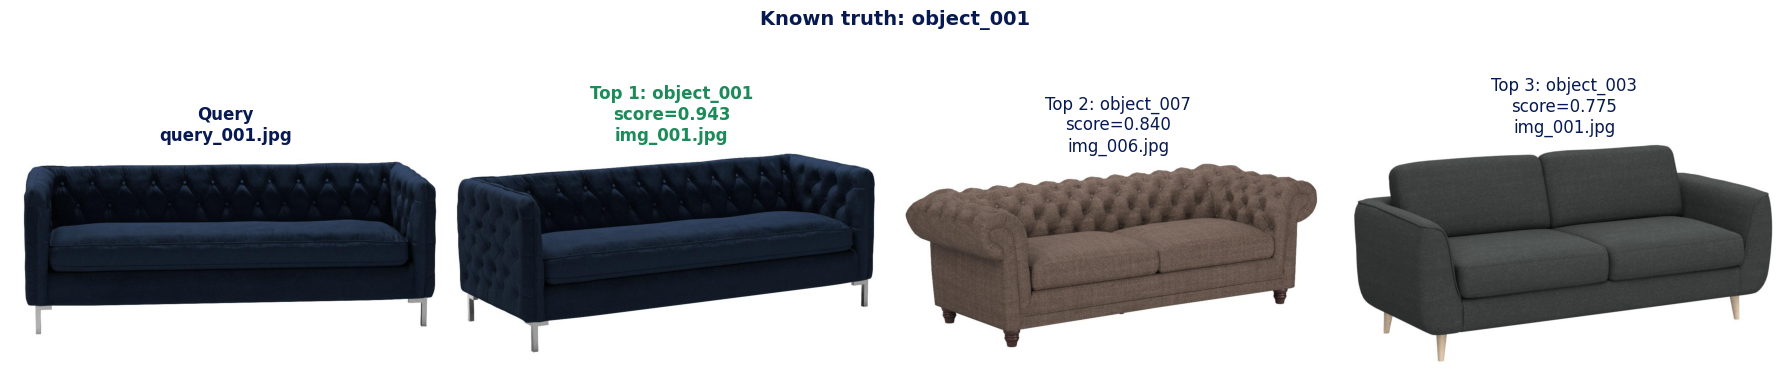

In [122]:
PALETTE = {
    "blue": "#071951",
    "coral": "#ff5757",
    "orange": "#f9b22f",
    "green": "#1c8b5a",
}


def lookup_true_object(query_name):
    if not LABELS_PATH.exists():
        return None
    labels_df = pd.read_csv(LABELS_PATH)
    if labels_df.empty or "query_name" not in labels_df.columns or "true_object" not in labels_df.columns:
        return None
    match = labels_df[labels_df["query_name"].astype(str).eq(query_name)]
    if match.empty:
        return None
    value = match.iloc[0]["true_object"]
    if pd.isna(value) or str(value).strip() == "":
        return None
    return str(value).strip()


def visualize_query_results(query_path, results, true_object=None, top_k=3):
    shown_results = results[:top_k]
    fig, axes = plt.subplots(1, len(shown_results) + 1, figsize=(4.5 * (len(shown_results) + 1), 4.8))
    axes = np.array(axes).reshape(-1)

    axes[0].imshow(load_rgb(query_path))
    axes[0].set_title(f"Query\n{query_path.name}", color=PALETTE["blue"], fontweight="bold")
    axes[0].axis("off")

    for rank, result in enumerate(shown_results, start=1):
        ax = axes[rank]
        object_id = result["object_id"]
        is_correct = true_object is not None and object_id == true_object
        title_color = PALETTE["green"] if is_correct else (PALETTE["coral"] if rank == 1 else PALETTE["blue"])
        ax.imshow(load_rgb(Path(result["image_path"])))
        ax.set_title(
            f"Top {rank}: {object_id}\nscore={result['score']:.3f}\n{result['image_name']}",
            color=title_color,
            fontweight="bold" if rank == 1 or is_correct else "normal",
        )
        ax.axis("off")

    if true_object:
        fig.suptitle(f"Known truth: {true_object}", color=PALETTE["blue"], fontsize=14, fontweight="bold")
    else:
        fig.suptitle("No known truth label for this query", color=PALETTE["blue"], fontsize=14, fontweight="bold")

    plt.tight_layout()
    plt.show()


true_object = lookup_true_object(selected_query.name)
visualize_query_results(selected_query, single_query_results, true_object=true_object, top_k=3)

<a id="search-every-query"></a>

## 11. Search Every Query Image

This runs the same search for every image in `data/query/` and saves a simple results table.

In [123]:
MIN_ACCEPT_SCORE = 0.50
MIN_ACCEPT_MARGIN = 0.03

all_rows = []

for query_path in tqdm(query_paths, desc="Searching queries"):
    results = search_query(query_path, top_k_images=30, top_k_objects=5)
    ranked_ids = [result["object_id"] for result in results]
    ranked_scores = [result["score"] for result in results]
    true_object = lookup_true_object(query_path.name)

    top1_object = ranked_ids[0] if ranked_ids else None
    top1_score = ranked_scores[0] if ranked_scores else None
    second_score = ranked_scores[1] if len(ranked_scores) > 1 else None
    margin = (top1_score - second_score) if top1_score is not None and second_score is not None else None
    accepted = (
        top1_object is not None
        and top1_score is not None
        and margin is not None
        and top1_score >= MIN_ACCEPT_SCORE
        and margin >= MIN_ACCEPT_MARGIN
    )
    pred_object = top1_object if accepted else None

    all_rows.append({
        "query_name": query_path.name,
        "true_object": true_object,
        "top1_object": top1_object,
        "top1_score": top1_score,
        "second_score": second_score,
        "margin": margin,
        "pred_object": pred_object,
        "accepted": accepted,
        "top3_objects": ranked_ids[:3],
        "top3_scores": ranked_scores[:3],
        "top1_correct": bool(true_object and top1_object == true_object),
        "top3_correct": bool(true_object and true_object in ranked_ids[:3]),
    })

results_df = pd.DataFrame(all_rows)
results_df.to_csv(OUTPUTS_DIR / "query_results.csv", index=False)

print("Acceptance rule:", f"score >= {MIN_ACCEPT_SCORE}", "and", f"margin >= {MIN_ACCEPT_MARGIN}")
display(results_df)
print("Saved:", OUTPUTS_DIR / "query_results.csv")

Searching queries: 100%|██████████| 20/20 [00:00<00:00, 33.97it/s]

Acceptance rule: score >= 0.5 and margin >= 0.03


,query_name,true_object,top1_object,top1_score,second_score,margin,pred_object,accepted,top3_objects,top3_scores,top1_correct,top3_correct
0,query_001.jpg,object_001,object_001,0.943413,0.839619,0.103794,object_001,True,"[object_001, object_007, object_003]","[0.9434130191802979, 0.839618980884552, 0.7750...",True,True
1,query_002.jpg,object_002,object_002,0.909108,0.857035,0.052074,object_002,True,"[object_002, object_006, object_014]","[0.9091083407402039, 0.8570345044136047, 0.855...",True,True
2,query_003.jpg,object_003,object_015,0.877913,0.877632,0.000281,None,False,"[object_015, object_005, object_020]","[0.877913236618042, 0.8776317834854126, 0.8715...",False,False
3,query_004.jpg,object_004,object_011,0.866469,0.860554,0.005915,None,False,"[object_011, object_015, object_004]","[0.8664686679840088, 0.8605537414550781, 0.833...",False,True
4,query_005.jpg,object_005,object_005,0.923991,0.886434,0.037557,object_005,True,"[object_005, object_020, object_015]","[0.9239914417266846, 0.8864343762397766, 0.876...",True,True
5,query_006.jpg,object_006,object_006,0.853254,0.809915,0.043339,object_006,True,"[object_006, object_004, object_002]","[0.8532536029815674, 0.8099147081375122, 0.793...",True,True
6,query_007.jpg,object_007,object_020,0.753999,0.750071,0.003928,None,False,"[object_020, object_014, object_007]","[0.7539985179901123, 0.7500707507133484, 0.743...",False,True
7,query_008.jpg,object_008,object_008,0.870929,0.826495,0.044434,object_008,True,"[object_008, object_019, object_014]","[0.8709290027618408, 0.8264952898025513, 0.821...",True,True
8,query_009.jpg,object_009,object_009,0.921232,0.840870,0.080362,object_009,True,"[object_009, object_016, object_005]","[0.9212322235107422, 0.8408703804016113, 0.808...",True,True
9,query_010.jpg,object_010,object_010,0.910295,0.856950,0.053345,object_010,True,"[object_010, object_019, object_006]","[0.9102952480316162, 0.8569501042366028, 0.848...",True,True


Saved: /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/workshop_materials/outputs/query_results.csv


<a id="prediction-statistics"></a>

## 13. Prediction Statistics

These summary tables and graphs help explain how the retrieval system behaved on the current query set.

Use them to discuss acceptance/rejection, Top-1 accuracy, Top-3 retrieval, score confidence, and margin confidence.


In [124]:
stats_df = results_df.copy()

stats_df["is_known"] = stats_df["true_object"].apply(lambda value: pd.notna(value) and str(value).strip() != "")
stats_df["final_correct"] = np.where(
    stats_df["is_known"],
    stats_df["accepted"] & stats_df["pred_object"].eq(stats_df["true_object"]),
    ~stats_df["accepted"],
)
stats_df["top1_correct_known"] = stats_df["is_known"] & stats_df["top1_correct"]
stats_df["top3_correct_known"] = stats_df["is_known"] & stats_df["top3_correct"]
stats_df["decision"] = np.where(stats_df["accepted"], "accepted", "rejected")

known_count = int(stats_df["is_known"].sum())
total_count = len(stats_df)

summary_rows = [
    {"metric": "Total queries", "value": total_count},
    {"metric": "Known queries", "value": known_count},
    {"metric": "Unknown queries", "value": total_count - known_count},
    {"metric": "Accepted predictions", "value": int(stats_df["accepted"].sum())},
    {"metric": "Rejected predictions", "value": int((~stats_df["accepted"]).sum())},
    {"metric": "Top-1 correct known", "value": int(stats_df["top1_correct_known"].sum())},
    {"metric": "Top-3 contains truth known", "value": int(stats_df["top3_correct_known"].sum())},
    {"metric": "Final decision correct", "value": int(stats_df["final_correct"].sum())},
    {"metric": "Top-1 accuracy on known", "value": stats_df["top1_correct_known"].sum() / known_count if known_count else np.nan},
    {"metric": "Top-3 accuracy on known", "value": stats_df["top3_correct_known"].sum() / known_count if known_count else np.nan},
    {"metric": "Final decision accuracy", "value": stats_df["final_correct"].mean() if total_count else np.nan},
    {"metric": "Average Top-1 score", "value": stats_df["top1_score"].mean()},
    {"metric": "Average margin", "value": stats_df["margin"].mean()},
]

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUTPUTS_DIR / "prediction_statistics.csv", index=False)

object_stats_df = (
    stats_df[stats_df["is_known"]]
    .groupby("true_object", dropna=False)
    .agg(
        queries=("query_name", "count"),
        top1_correct=("top1_correct_known", "sum"),
        top3_correct=("top3_correct_known", "sum"),
        accepted=("accepted", "sum"),
        avg_top1_score=("top1_score", "mean"),
        avg_margin=("margin", "mean"),
    )
    .reset_index()
)
object_stats_df["top1_accuracy"] = object_stats_df["top1_correct"] / object_stats_df["queries"]
object_stats_df["top3_accuracy"] = object_stats_df["top3_correct"] / object_stats_df["queries"]
object_stats_df.to_csv(OUTPUTS_DIR / "prediction_statistics_by_object.csv", index=False)

display(summary_df)
display(object_stats_df.sort_values(["top1_accuracy", "queries"], ascending=[True, False]).head(20))
print("Saved:", OUTPUTS_DIR / "prediction_statistics.csv")
print("Saved:", OUTPUTS_DIR / "prediction_statistics_by_object.csv")


,metric,value
0,Total queries,20.000000
1,Known queries,20.000000
2,Unknown queries,0.000000
3,Accepted predictions,13.000000
4,Rejected predictions,7.000000
5,Top-1 correct known,15.000000
6,Top-3 contains truth known,18.000000
7,Final decision correct,12.000000
8,Top-1 accuracy on known,0.750000
9,Top-3 accuracy on known,0.900000


,true_object,queries,top1_correct,top3_correct,accepted,avg_top1_score,avg_margin,top1_accuracy,top3_accuracy
2,object_003,1,0,0,0,0.877913,0.000281,0.0,0.0
3,object_004,1,0,1,0,0.866469,0.005915,0.0,1.0
6,object_007,1,0,1,0,0.753999,0.003928,0.0,1.0
17,object_018,1,0,0,1,0.872042,0.030320,0.0,0.0
18,object_019,1,0,1,0,0.872032,0.019304,0.0,1.0
0,object_001,1,1,1,1,0.943413,0.103794,1.0,1.0
1,object_002,1,1,1,1,0.909108,0.052074,1.0,1.0
4,object_005,1,1,1,1,0.923991,0.037557,1.0,1.0
5,object_006,1,1,1,1,0.853254,0.043339,1.0,1.0
7,object_008,1,1,1,1,0.870929,0.044434,1.0,1.0


Saved: /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/workshop_materials/outputs/prediction_statistics.csv
Saved: /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/workshop_materials/outputs/prediction_statistics_by_object.csv


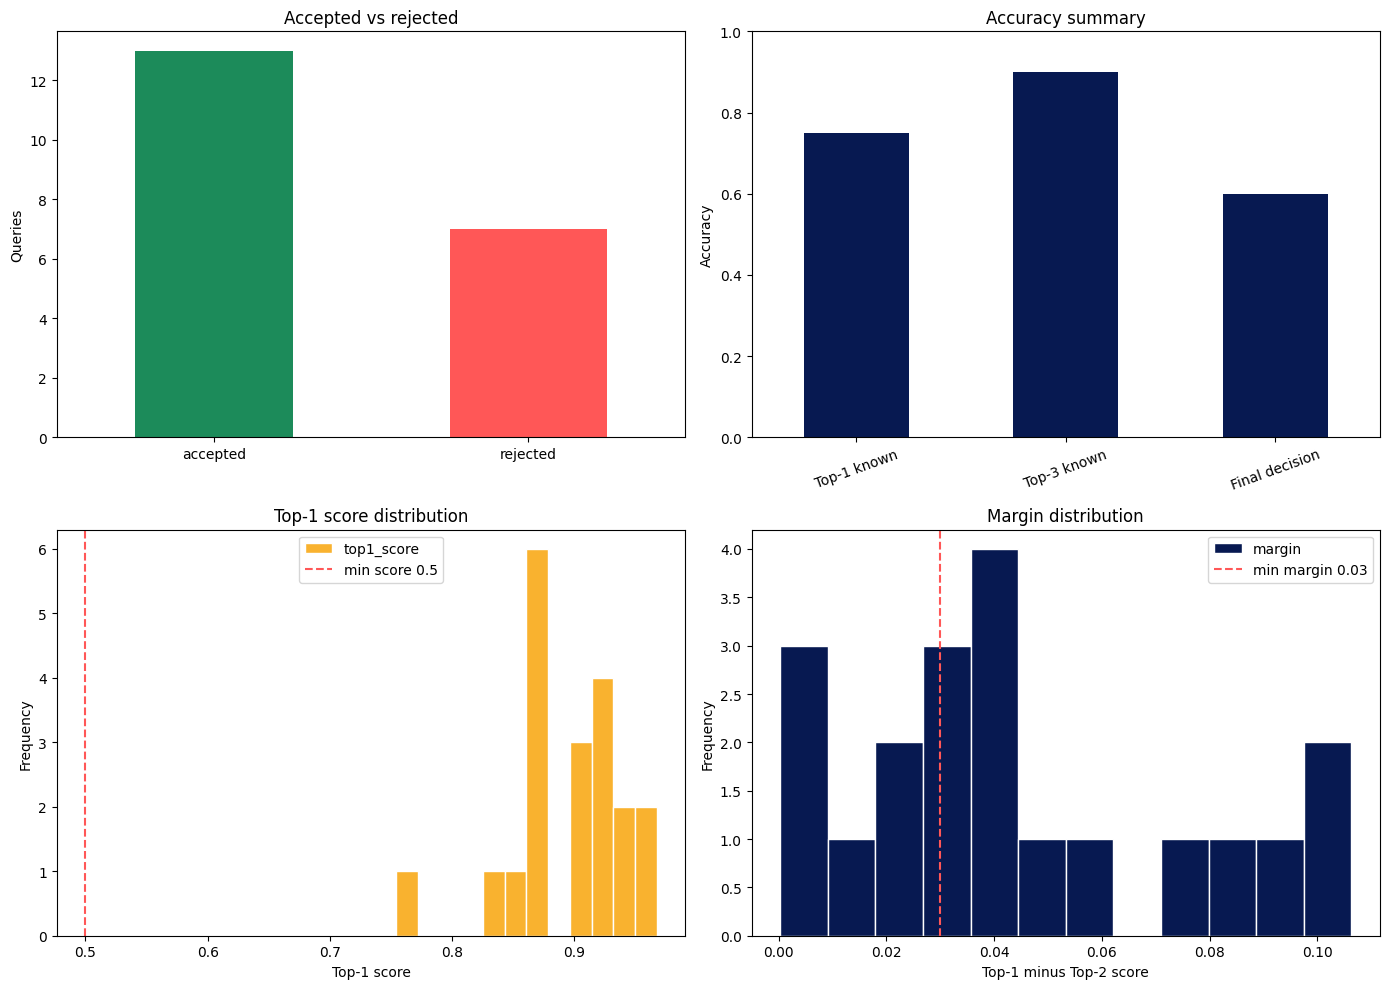

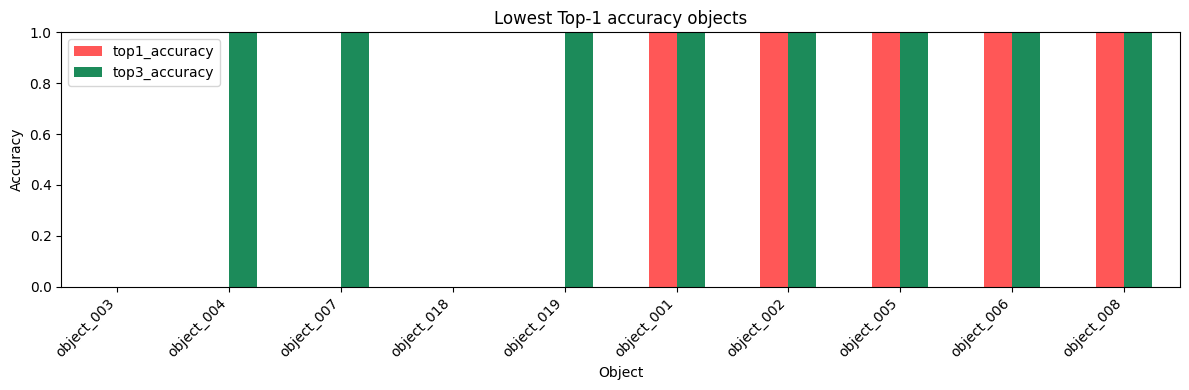

In [125]:
plot_palette = globals().get("PALETTE", {
    "blue": "#071951",
    "coral": "#ff5757",
    "orange": "#f9b22f",
    "green": "#1c8b5a",
})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.reshape(-1)

decision_counts = stats_df["decision"].value_counts().reindex(["accepted", "rejected"], fill_value=0)
decision_counts.plot(kind="bar", ax=axes[0], color=[plot_palette["green"], plot_palette["coral"]])
axes[0].set_title("Accepted vs rejected")
axes[0].set_xlabel("")
axes[0].set_ylabel("Queries")
axes[0].tick_params(axis="x", rotation=0)

accuracy_values = pd.Series({
    "Top-1 known": stats_df["top1_correct_known"].sum() / known_count if known_count else np.nan,
    "Top-3 known": stats_df["top3_correct_known"].sum() / known_count if known_count else np.nan,
    "Final decision": stats_df["final_correct"].mean() if total_count else np.nan,
})
accuracy_values.plot(kind="bar", ax=axes[1], color=plot_palette["blue"], ylim=(0, 1))
axes[1].set_title("Accuracy summary")
axes[1].set_xlabel("")
axes[1].set_ylabel("Accuracy")
axes[1].tick_params(axis="x", rotation=20)

stats_df["top1_score"].dropna().plot(kind="hist", bins=12, ax=axes[2], color=plot_palette["orange"], edgecolor="white")
axes[2].axvline(MIN_ACCEPT_SCORE, color=plot_palette["coral"], linestyle="--", label=f"min score {MIN_ACCEPT_SCORE}")
axes[2].set_title("Top-1 score distribution")
axes[2].set_xlabel("Top-1 score")
axes[2].legend()

stats_df["margin"].dropna().plot(kind="hist", bins=12, ax=axes[3], color=plot_palette["blue"], edgecolor="white")
axes[3].axvline(MIN_ACCEPT_MARGIN, color=plot_palette["coral"], linestyle="--", label=f"min margin {MIN_ACCEPT_MARGIN}")
axes[3].set_title("Margin distribution")
axes[3].set_xlabel("Top-1 minus Top-2 score")
axes[3].legend()

plt.tight_layout()
plt.show()

if not object_stats_df.empty:
    hardest_objects = object_stats_df.sort_values(["top1_accuracy", "queries"], ascending=[True, False]).head(10)
    ax = hardest_objects.plot(
        x="true_object",
        y=["top1_accuracy", "top3_accuracy"],
        kind="bar",
        figsize=(12, 4),
        color=[plot_palette["coral"], plot_palette["green"]],
        ylim=(0, 1),
    )
    ax.set_title("Lowest Top-1 accuracy objects")
    ax.set_xlabel("Object")
    ax.set_ylabel("Accuracy")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


<a id="optional-single-item-visualizations"></a>

## 14. Optional Single-Item Visualizations

This optional final step triggers `scripts/make_single_item_visualizations.py` and exports cards for the first 20 workshop query results.

The images are saved in `outputs/visualizations/`. The code is commented out by default because it may reload DINOv2 and process local images.


In [126]:
# Optional visualization export. Uncomment this cell after Section 12 has saved query_results.csv.
#
import subprocess
import sys

VISUALIZATION_SCRIPT = WORKSHOP_DIR.parent / "scripts" / "make_single_item_visualizations.py"
VISUALIZATION_OUTPUT_DIR = OUTPUTS_DIR / "visualizations"

visualization_command = [
    sys.executable,
    str(VISUALIZATION_SCRIPT),
    "--variant", "raw",
    "--examples", "first",
    "--limit", "20",
    "--query-dir", str(QUERY_DIR),
    "--gallery-dir", str(GALLERY_DIR),
    "--results-path", str(OUTPUTS_DIR / "query_results.csv"),
    "--metadata-path", str(OUTPUTS_DIR / "gallery_metadata.csv"),
    "--embeddings-path", str(OUTPUTS_DIR / "gallery_embeddings.npy"),
    "--output-dir", str(VISUALIZATION_OUTPUT_DIR),
    "--score-threshold", str(MIN_ACCEPT_SCORE),
    "--margin-threshold", str(MIN_ACCEPT_MARGIN),
]

print("Running:", " ".join(visualization_command))
completed = subprocess.run(
    visualization_command,
    cwd=WORKSHOP_DIR.parent.parent,
    text=True,
    capture_output=True,
)

if completed.stdout:
    print(completed.stdout)
if completed.stderr:
    print(completed.stderr)
if completed.returncode != 0:
    raise RuntimeError(f"Visualization script failed with exit code {completed.returncode}")

print("Visualization cards saved to:", VISUALIZATION_OUTPUT_DIR)


Running: /Library/Developer/CommandLineTools/usr/bin/python3 /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/scripts/make_single_item_visualizations.py --variant raw --examples first --limit 20 --query-dir /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/workshop_materials/data/query --gallery-dir /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/workshop_materials/data/gallery --results-path /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/workshop_materials/outputs/query_results.csv --metadata-path /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/workshop_materials/outputs/gallery_metadata.csv --embeddings-path /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/workshop_materials/outputs/gallery_embeddings.npy --output-dir /Users/memerchik/Documents/GitHub/aister_prototypes/step_1/workshop_materials/outputs/visualizations --score-threshold 0.5 --margin-threshold 0.03
Generated 20 visualization(s).
Index: /Users/memerchik/Docum

<a id="try-it-yourself"></a>

## 15. Try It Yourself

Workshop exercise:

1. Add a new object folder inside `data/gallery/`, for example `object_003/`.
2. Put two or more images of that object into the folder.
3. Add one or more query images into `data/query/`.
4. If you know the correct answer, add a row to `data/query_labels.csv`.
5. Rerun the notebook from **Load Images from the Workshop Folders** onward.

Things to test:

- Does the same object work from a different angle?
- What happens if the background changes?
- What happens with a visually similar but different object?
- Does Top-3 help when Top-1 is wrong?

This is the core idea of the prototype: embeddings do not give a perfect answer, but they can quickly produce useful visual candidates for human inspection.